# Attention !!!
- Please write or take a screenshot of all answers in the pdf file. You won't be graded if there is no pdf file in the submission.
- Only TODO 1, 2, 3, 4, 5, 6, 10, 11 will be graded.
- **Extra credit:** 1% of total grade for Com Eng Math 2 for TODO 7, 8, 9 (1/3 each.)

# Sampling

Sampling is a process that is very important for writing simulations. In this section, you will try to sample from some common distributions.

TODO#1: Write functions that samples from the following distribution
1. $\mathcal{N}(0,1)\\$
2. $Bernoulli(0.3)\\$
3. $B(10, 0.3)\\$
4. $Multinomial(n=10, p=[0.3,0.2,0.5])\\$
5. $U(0,1)\\$
6. $T(0,1)$; $T(a,b)$ is defined as a function with a shape of a triangle that pass through point $(a,0)$, $(b,0)$, and $(\frac{a+b}{2}, K):\frac{(b-a)K}{2}=1\\$.

Capture screenshot of the histogram for each of the distribution and paste them on the pdf file. The example is shown below.

Hint: see scipy.stats for common distributions.
[plt.hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) should be helpful for plotting histograms

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, bernoulli, binom, multinomial, uniform, triang


def sample_normal(sample_size=10, mu=0, std=1):
  # TODO#1.1: #
  return norm.rvs(loc=mu, scale=std, size=sample_size)


def sample_bernoulli(sample_size=10, p=0.3):
  # TODO#1.2:
  return bernoulli.rvs(p=p, size=sample_size)


def sample_binomial(sample_size=10, n=10, p=0.3):
  # TODO#1.3:
  return binom.rvs(n=n, p=p, size=sample_size)


def sample_multinomial(sample_size=10, n=100, p=[0.3, 0.2, 0.5]):
  # TODO#1.4:
  return multinomial.rvs(n=100, p=p, size=sample_size)


def sample_uniform(sample_size=10, from_x=0, to_x=1):
  # TODO#1.5:
  return uniform.rvs(loc=from_x, scale=to_x-from_x, size=sample_size)


def sample_triangle(sample_size=10, a=0, b=1):
  # TODO#1.6:
  return triang.rvs(0.5, loc=a, scale=b-a, size=sample_size)

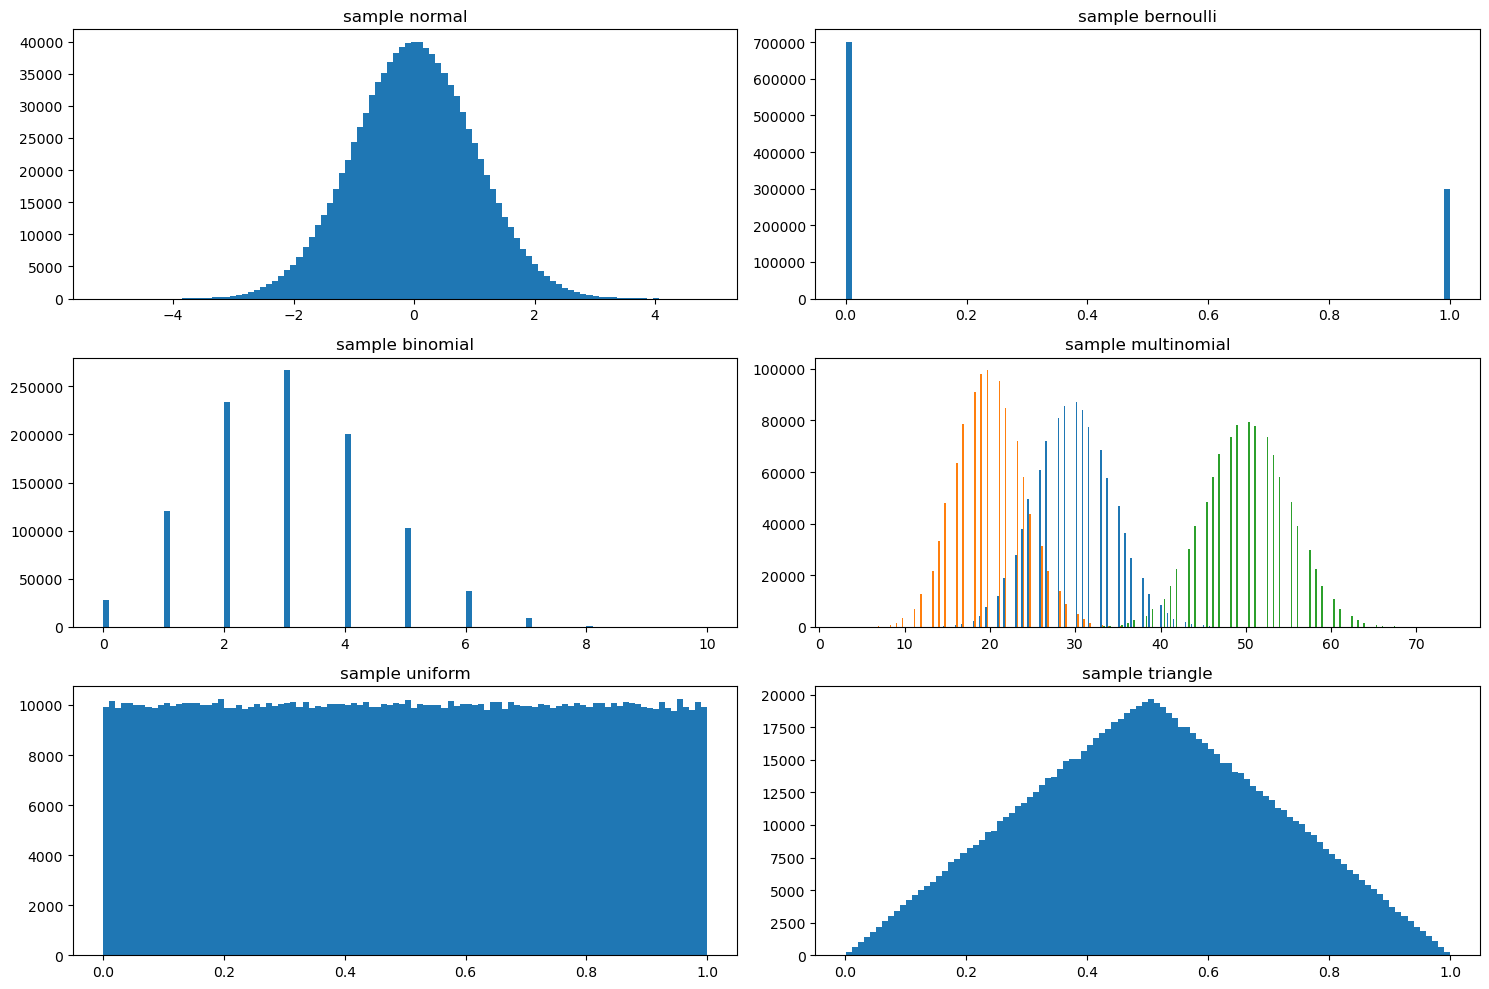

In [2]:
sample_size = 1000000

plt.figure(figsize=(15, 10))
for i, sample_fn in enumerate([sample_normal, sample_bernoulli, sample_binomial, sample_multinomial, sample_uniform, sample_triangle]):
    name = sample_fn.__name__.split("_")[-1]
    plt.subplot(3, 2, i+1)
    s = sample_fn(sample_size=sample_size)
    count, bins, ignored = plt.hist(s, 100, density=False)
    plt.title(f"sample {name}")
plt.tight_layout()
plt.show()

# Law of large number

### Law of large number

**TODO#2:** Using a sampling function from TODO#1.1, Plot the graph that shows the relation between an empirical mean and sampling size from 1 up to 10000.
What does the graph imply about the difference between the empirical mean and the theoritical mean?

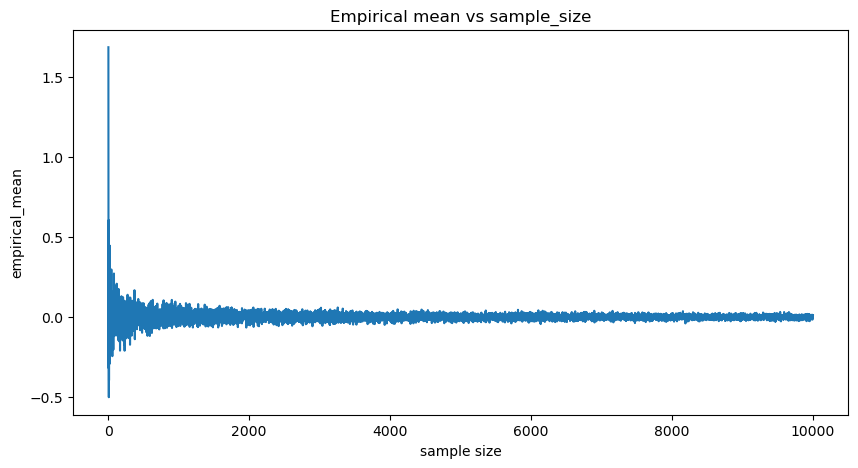

In [5]:
plt.figure(figsize=(10, 5))
l = []
for sample_size in range(1, 10_001):
    s = sample_normal(sample_size=sample_size)
    empirical_mean = s.mean()
    l.append(empirical_mean)

plt.xlabel("sample size")
plt.ylabel("empirical_mean")
plt.title("Empirical mean vs sample_size")
plt.plot(range(1, 10_001), l)
plt.show()

**TODO 2 Answer**: 

The empirical mean trend to be 0 when sampling on a larger `sample_size`

### Law of large number for histogram

The histogram is used to approximate the PDF of an unknown distribution.
The bin in the histogram represents the frequency of the event happening inside the bin range.

**TODO#3:** Given a fix bin number of 40. Plot the histogram of the data sampling from the function, `sample_normal(n, 0, 1)`, for different sizes of sample: 500, 1k, 5k and 10k.
Compare and explain the relation between the approximation given by the histogram and the true PDF for each of the sample size.

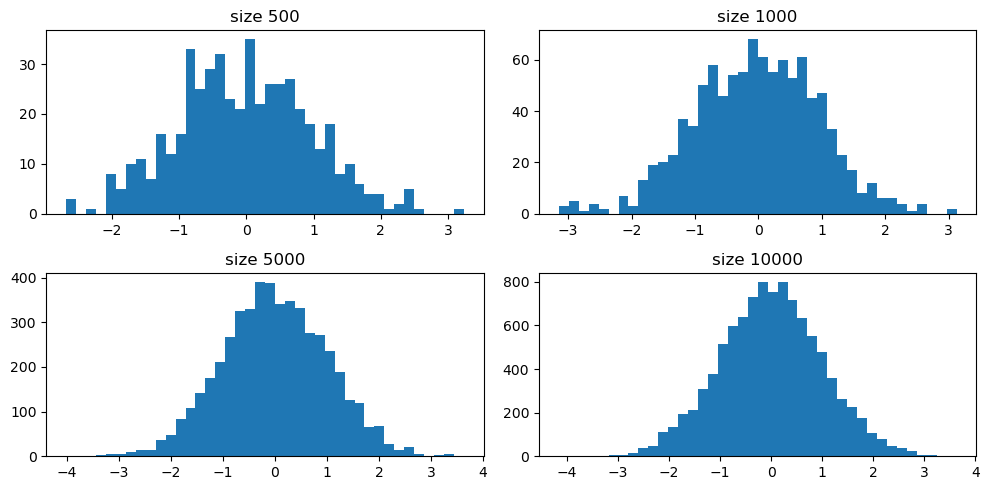

In [6]:
plt.figure(figsize=(10, 5))
for i, sample_size in enumerate([500, 1000, 5000, 10_000]):
    plt.subplot(2, 2, i+1)
    s = sample_normal(sample_size=sample_size, mu=0, std=1)
    count, bins, ignored = plt.hist(s, 40, density=False)
    plt.title(f"size {sample_size}")
plt.tight_layout()
plt.show()

**TODO 3 Answer:** 

The bin around 0 has large amount of number and shape of histograms is trend to be $N(0, 1)$-pdf when the `sample_size` is bigger 

## Central limit theorem

In this part we will use the Central Limit Theorem to approximate the true probabity of getting more than 40 heads when an unfair coin, with the probability 0.3 of being head, is tossed 100 times.


**TODO#4:** Simulate multiple coin tosses to construct a histrogram from the outcomes. Plot the histogram. Hint: x-axis should represents the number of heads when the coin is tossed 100 times. Does this histogram looks like a normal distribution?

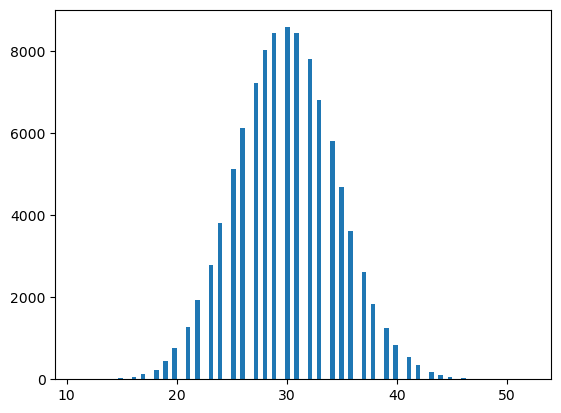

In [5]:
s = sample_binomial(n=100, p=0.3, sample_size=100_000)
sorted(s)
plt.hist(s, bins=100)
plt.show()

**TODO 4 Answer:**

It looks like a normal distribution!

**TODO#5:** Use CLT to find the probability of getting more than 40 heads.

**TODO#6:** Compare and find the difference between CLT's approximation and the actual probability using the binomial distribution.

**TODO 5,6 Answer:**

$\text{let } X \sim Bin(100, 0.3)\\ \text{Mean and variance for binomial distribution} $

\begin{align*}
    \mu &= np \\
    \sigma^2 &= np(1-p)
\end{align*}

$ \text{Assume this mean and variance as a Parameters of Normal distribution} \Rightarrow Y \sim N(\mu, \sigma^2) \Rightarrow P(X > 40) \approx P(Y > 40)$


In [6]:
n = 100
p = 0.3

X = binom(n = n, p = p)
Y = norm(X.mean(), X.std())

prob_CLT = Y.sf(40)
prob_BIN = X.sf(40)
print(prob_CLT, prob_BIN)

0.01454816587062609 0.012498407166438177


# Algebra of Random Variables

Given an independent random variable $X$ and $Y$, such that $X \sim F$ and $Y \sim U(3,5)$. The summation of those two is written as $Z = X + Y$ and the PDF of $F$ is defined below.
$$
F(X) =
\begin{cases}
0.1, & -2<=X<=0\\
0.4, & 0<X<=2 \\
\end{cases}
$$
**TODO#7:** Find $P( 3 < Z < 5 )$.

Adding two RVs the result pdf is the convolution between the pdf

In [19]:
from scipy.signal import fftconvolve

space = 10_000_000
x = np.linspace(-5, 5, space)
dx = (x[-1] - x[0]) / space

U35 = np.where((3 <= x) & (x <= 5), 1/(5-3), 0)
F = np.select( [x<=-2, x<=0, x<=2, x>2], [0, 0.1, 0.4, 0])

Z = fftconvolve(U35, F, mode='same') * dx # fft is discrete so we must multiply dx after convolution

P = np.sum(np.where((3 <= x) & (x <= 5), Z, 0)) * dx # integrate

print( "Prob = ", P)

Prob =  0.49999985


The answer is approximate $P=0.5$

# Correlation

The correlation captures the linear relationshi between two sets of random variables. The higher magnitude of the correlation indicates a stronger relationship.


**TODO#8:** Find the correlation of $X$ and $Y = X + A$, given that $X \sim U(-1,1)$ and
1. $A = 10\\$
2. $A \sim U(-1,1)\\$
3. $A \sim U(-10,10)\\$
4. $A \sim U(-100,100)\\$


**TODO#9:** From the results in TODO#8, answer following questions
1. Does the correlation decrease as we increase the randomness of A ?
2. Explain the result when we change from $A \sim U(-10,10)$ to $A \sim U(9090,10010)$. Hint: Compare the result with $A$ and $A + 10000: A \sim U(-10,10) $

**Answer TODO8:**

From

1.

\begin{align*}
VAR[Y] = VAR[X + A] &= VAR[X] + VAR[A] + Cov(X, A) = VAR[X] + VAR[A] \because X,A \text{ are independent}  \\
\end{align*}

2.

\begin{align*}
Cov(X, Y) = Cov(X, X+A) &= Cov(X, X) + Cov(X, A) \\
&= VAR[X]
\end{align*}

3.

\begin{align*}
    \rho = \frac{Cov(X, Y)}{\sqrt{VAR[X]\cdot VAR[Y]}} = \frac{VAR[X]}{\sqrt{VAR[X]\cdot(VAR[X] + VAR[A])}}
\end{align*}

4.

\begin{align*}
    VAR[X] = \frac{(1-(-1))^2}{12} = \frac{1}{3}
\end{align*}


**ANSWER**

1. 

\begin{align*}
VAR[A] &= 0\ (\because A \text{ is constant}) \\
\therefore \rho &= 1 
\end{align*}
(This is the property of Correlation)


2. 

\begin{align*}
VAR[A] &= \frac{(1-(-1))^2}{12} = \frac{1}{3} \\
\therefore \rho &= \frac{1/3}{\sqrt{(1/3)(2/3)}} = \frac{1}{\sqrt{2}}
\end{align*}

3.

\begin{align*}
VAR[A] &= \frac{(10-(-10))^2}{12} = \frac{100}{3} \\
\therefore \rho &= \frac{1/3}{\sqrt{(1/3)(101/3)}} = \frac{1}{\sqrt{101}}
\end{align*}

4.

\begin{align*}
VAR[A] &= \frac{(100-(-100))^2}{12} = \frac{10,000}{3} \\
\therefore \rho &= \frac{1/3}{\sqrt{(1/3)(10,001/3)}} = \frac{1}{\sqrt{10,001}}
\end{align*}


**TODO 9 ANSWER:**

1. Yes, the correlation does decrease as we increase the randomness of $A$. As we can see in TODO#8
2. The result remain The same as we've seen in 8.1-8.4 the variance of uniform distribution care only the difference from lower and upper bound and both 10-(-10) = 10,010-9,090 = 20.
    The probabilistic reason is because we shift the center by 10,000. (For the signal processing view the addition of Random variables is a convolution of its pdf. We see a constant 10,000 as an impulse and convolute it with $U(-10, 10)$ so the center of Uniform distribution is shift to 10,000.)

# Hamtaro and his cloud storage empire.



After the success in the manufacturing business. Hamtaro wants to expand his business into a new sector.
Since cloud computing is currently booming, he decides to enter into the cloud storage business.

The storage disk that Hamtaro uses can operate only in the temperature of $[0,30]$ degree Celcius. The disk has the prabability of a read failure $P(Fail|t) = \frac{0.97}{2250}(t-15)^2+0.001$ where $t$ is the operating temperature.
<!-- Hamtaro's disks has a special architecture that can be  simultaneously read by infinite requests at the same time. However, a failure of one request will cause all of its parallels to fail. -->

Since Hamtoro doesn't want any failures in his service, he decides to buy a super luxury air-conditioning system to control the temperature in his data warehouse. Even if the air conditioner is extremely expensive, the room temperature is still not stable. When Hamtaro tries to set the tempurature to $\mu$, the actual temperature is random and can be modeled by $t\sim U(\mu-1,\mu+1)$.

**TODO#10:** Answer the following questions.
1. What is the temperature that Hamtaro should set the air conditioner to? Justify your answer.
2. What is the probability of failure at the temperature used in part 1?
<!-- 3. If Hamtaro want to handle 10k concurrent requests, what is the minimum disks should Hamtoro has to make 99.99% of disk availability and how should he split the workloads? Hamtaro connects the all the disks in parallel. The read request will fail if all disks fail to be read at the same time. -->
3. What is the minimum number of disks that Hamtoro has to use to make sure that the probability of having more than 1 failure in 10k requests is less than 0.01\%? Hamtaro connects the all the disks in parallel. The read request will fail if all disks fail to at the same time.
4. **Extra** The temperature is now modeled by $t\sim \mathcal{N}(\mu,9)$ instead of $t\sim U(\mu-1,\mu+1)$. Repeat question 1-3.

**Hint:** `scipy.integrate.quad` can help you do integration.

1.

Minimize by using derivative

\begin{align*}
\frac{dP(Fail|t)}{dt} &= 0 \\
t-15 &= 0 \\
t &= 15
\end{align*}

2.

\begin{align*}
 t &\sim U(14, 16) \\
q &= E[P(Fail|t)] \\
&= \int_{14}^{16} \frac{1}{16-14} P(Fail|t)\ dt \\
    &=\frac{1}{2}\int_{14}^{16} \frac{0.97}{2250}(t-15)^2+0.001\ dt \\
 &= 0.0011437
\end{align*}

3.

from 2. we know the probability that the disk will fail $q=0.0011437$.

If we have $n$ disks and not fail $k$ disks $\Leftarrow$ **Binomial**, 

- Prob that all disks fail = ${n \choose 0}q^n =  q^n\\$

Prob of number fail on request

- fail 0 request: ${10,000 \choose 0} ( 1-q^n )^{10,000} = (1-q^n)^{10,000} \\$
- fail 1 request: ${10,000 \choose 1} ( 1-q^n )^{9,999}(q^n)^1 = 10,000( 1-q^n )^{9,999}q^n\\$
- More than 1 request: $1 - (1-q^n)^{10,000} - 10,000( 1-q^n )^{9,999}q^n\\$

fix equation for handling floating point error

\begin{align*}
     1 - (1-q^n)^{10,000} - 10,000( 1-q^n )^{9,999}q^n &< 0.0001 \\
     (1-q^n)^{10,000} + 10,000( 1-q^n )^{9,999}q^n &> 0.9999 \\
     ( 1-q^n )^{9,999}( (1 - q^n) + 10,000q^n ) &> 0.9999 \\
     9,999\log(1-q^n) + \log(1 + 9,999q^n) &> \log 0.9999 \\
     9,999\log(1-q^n) + \log(1/9,999 + q^n) + \log9,999 &> \log 0.9999 \\
     9,999\log(1-q^n) + \log(1/9,999 + q^n) &> \log 0.9999/9,999 \\
     9,999\log(1-q^n) + \log(1/9,999 + q^n) &> -4\log10 \\
\end{align*}

iterate n for this question

4.

- 4.1 is same answer as 1


- 4.2 

\begin{align*}
 t &\sim N(15, 3^2) \\
 p &= E[P(Fail|t)] \\
   &= \int_{-\infty}^{\infty} N(t; 15, 3^2) P(Fail|t)\ dt \\
 &=  0.0048800
\end{align*}

- 4.3 is same as 3

In [10]:
import scipy.integrate as integrate
import scipy.special as sc

def expected_prob_bin(t): # uniform T
    return 0.5*(0.97 * (t - 15)**2 / 2250 + 0.001)
def expected_prob_norm(t):
    return norm.pdf(t, loc = 15, scale=3) * (0.97 * (t - 15)**2 / 2250 + 0.001)

def solve(expected_fn, a, b, task="1-3"):
    print(f"{task:=^60}")
    q = integrate.quad(expected_fn, a, b)[0]
    print("Fail probability:", q)
    n = 1
    while True:
        lhs = 9999*sc.log1p(-q**n) + np.log(1/9_999 + q**n)
        rhs = -4 * np.log(10)
        if lhs > rhs:
            break
        n += 1

    print(f"n={int(n):,} disks")


solve(expected_prob_bin, 14, 16, task="1-3")
solve(expected_prob_norm, -np.inf, np.inf, task="4.1-4.3")

============================1-3=============================
Fail probability: 0.0011437037037037036
n=2 disks
==========================4.1-4.3===========================
Fail probability: 0.004880000000025307
n=3 disks


# Moontaro
![picture](https://i.redd.it/mcveltqx2j071.png)

Recently, cryptocurrency investment has become extremely popular due to its extraordinarily high rates of return. Though many people consider it a risky investment, Hamtaro does not want to miss this opportunity and start gathering information about these coins. His research suggests that four coins, namely $a$, $b$, $c$, and $d$, have a promising future to go to the moon.


Hamtaro wants to run simulations to validate his chances. As the value of the coins is non-deterministic, he models it sequentially based on their historical values (a.k.a. autoregressive model). The price of coin $i$ at day $t$ is formulated as

$p_{i,t} = p_{i,t-1} \times r_{i,t}$, where $i \in \{a, b, c, d\}$, and  $p_{i, 0} = 10$.

The rates $r_{i,t}$, are drawn from a multivariant guassian distribution $\mathcal{N}(\mathbf{\mu}, \mathbf{\Sigma})$, where $\mu = [1.003, 1.002, 1.004, 1.004]^T$ and $\mathbf{\Sigma}$ as given below:

$\mathbf{\Sigma}$ | a | b | c | d
--- | --- | --- | --- |---
a |  $10 \times 10^{-3}$ | $0$ | $4 \times 10^{-3}$ | $5 \times 10^{-3}$
b |  $0$  | $3 \times 10^{-3}$ | $0$ | $0$
c |  $4 \times 10^{-3}$  | $0$ | $12 \times 10^{-3}$| $2 \times 10^{-3}$
d |  $5 \times 10^{-3}$  | $0$ | $2 \times 10^{-3}$ | $15 \times 10^{-3}$


<!-- 1. Are $p_{a,t}$ and $p_{b,t}$ independent ? Why ?
2. Are $p_{a,t}$ and $p_{c,t}$ independent ? Why ?
3. Are $p_{a,t}$ and $p_{d,t}$ independent ? Why ? -->

**TODO11:**
1. Which pairs of coins are independent? Why?
2. Given the following definitions:
  - <b>Return</b> :  a coin price at day $T$ minus the price at day 0, i.e., the return of coin $i$ at day $T = p_{i,T} - p_{i, 0}$.
  - <b>Expected return</b> : the average return from 10000 distinct simulated end prices.
  
  Simulate the expected return for each coin if Hamtaro wants to sell his coins 30 and 180 days after buying $(T \in \{30, 180\})$.
  hint: you should write reusable functions to make your life easier.

3. Which coin has the highest probability of having profit (end price is higher than start price)? Compare the variance of the return with other coins.
4. How can the expected return be positive while having around 50\% chance of profitability?

After simulating the price of individual coins, Hamtaro now proposes seven investment strategies (portfolio) to maximize the profit. The detail of each strategy is shown in the table below.  

Strategy | Buy $a$ | Buy $b$ | Buy $c$ | Buy $d$ | Expected\[return\] | Variance\[return\] | Probability of having profit
---| --- |--- |--- | ---| --- | --- | ---
1  | 100% | 0%   | 0%  |    0%|  |  |
2  | 0%   | 100% | 0%  |    0%|  |  |
3  | 0%   | 0%   | 100%|    0%|  |  |
4  | 0%   | 0%   |   0%|  100%|  |  |
5  | 50%  | 50%  | 0%  |    0%|  |  |
6  | 50%  | 0%   | 50% |    0%|  |  |
7  | 50%  | 0%   |  0% |   50%|  |  |

5. Fill the empty values in the table (both $T = 30, 180$).
6. Which strategy yields the highest return?
7. Which strategy is the safest one?
8. Compare the variances between the stategy 6 and 7. What happens, and why is this the case? **Hint:** Consider cov($r_a$, $r_c$) and cov($r_a$, $r_d$).
9. From the problems above, come up with a general practice for good investment? Please also state your reasoning. You can include additional simulations to support the argument.

**TODO 11 Answer:**
1. (a,b), (b,c), (b, d) because **Covariance** = 0

2.

In [ ]:
from scipy.stats import multivariate_normal as mv_norm
mu = np.array([.003, .002, .004, .004]) + 1
cov = np.array([
    [10, 0, 4, 5],
    [0, 3, 0, 0],
    [4, 0, 12, 2],
    [5, 0, 2, 15]
]) * 10**-3

def fmt_array(a):
    return "".join(f'{f"{x:.3f}":<10}' for x in a)

def simulate(T):
    init_coins = [10, 10, 10, 10]
    end_coins = np.vstack([init_coins * mv_norm.rvs(mu, cov, T).prod(axis=0) for _ in range(10_000)])
    returns = end_coins-10

    avg_coins = np.mean(end_coins, axis=0)
    prob = np.mean(returns>0, axis=0)
    var = np.var(returns, axis=0)

    print(f"{' T = '+str(T)+' ':=^60}")
    print(f'{"Coin":<20}', (10*' ').join(['a','b','c','d']))
    print(f'{"Average Coins":<20}',      fmt_array(avg_coins) )
    print(f'{"Profit Probability":<20}', fmt_array(prob) )
    print(f'{"Returns Variance":<20}',   fmt_array(var) )

simulate(30)
simulate(180)

========================== T = 30 ==========================
Coin                 a          b          c          d
Average Coins        10.888    10.642    11.331    11.190    
Profit Probability   0.451     0.528     0.462     0.434     
Returns Variance     41.713    10.550    55.864    71.475    
========================= T = 180 ==========================
Coin                 a          b          c          d
Average Coins        16.927    14.497    19.796    21.079    
Profit Probability   0.391     0.553     0.400     0.345     
Returns Variance     1103.763  150.267   1944.606  4504.696  


3.

As you can see the output from the above cell. The highest probabilities is `coin b`, <br>
The return variance comparision between `coin b` and other coin, Found that `coin b` has very low variance (compare to other coins)

4.

Because the variance of the coin is very high even, The probability is around 50%. A few large gains of coin may have a positive expected return.

e.g.,

Coin c has a distribution where 50% of the time, it returns small losses -0.02, and 50% of the time, it returns larger gains +0.1. 

The expected return = $0.5(-0.02) + 0.5(0.1) = 0.04 > 0$

5.

# T = 30

| Strategies    | Buy A | Buy B | Buy C | Buy D | Expected\[return\] | Variance\[return\]    | Probability of having profit  |
|---------------|-------|-------|-------|-------|----------|--------|-------|
| Strategy 1    | 100%  | 0%    | 0%    | 0%    | 10.820   | 40.478 | 0.451 |
| Strategy 2    | 0%    | 100%  | 0%    | 0%    | 10.646   | 10.837 | 0.523 |
| Strategy 3    | 0%    | 0%    | 100%  | 0%    | 11.207   | 54.767 | 0.462 |
| Strategy 4    | 0%    | 0%    | 0%    | 100%  | 11.411   | 78.585 | 0.441 |
| Strategy 5    | 50%   | 50%   | 0%    | 0%    | 10.733   | 13.025 | 0.022 |
| Strategy 6    | 50%   | 0%    | 50%   | 0%    | 11.014   | 31.727 | 0.067 |
| Strategy 7    | 50%   | 0%    | 0%    | 50%   | 11.116   | 39.648 | 0.085 |

# T = 180

| Strategies    | Buy A | Buy B | Buy C | Buy D | Expected \[return\] | Variance\[return\]       | Probability of having profit  |
|---------------|-------|-------|-------|-------|----------|-----------|-------|
| Strategy 1    | 100%  | 0%    | 0%    | 0%    | 17.205   | 1261.448  | 0.395 |
| Strategy 2    | 0%    | 100%  | 0%    | 0%    | 14.342   | 143.384   | 0.549 |
| Strategy 3    | 0%    | 0%    | 100%  | 0%    | 19.839   | 2010.201  | 0.397 |
| Strategy 4    | 0%    | 0%    | 0%    | 100%  | 20.528   | 8412.626  | 0.354 |
| Strategy 5    | 50%   | 50%   | 0%    | 0%    | 15.774   | 351.903   | 0.212 |
| Strategy 6    | 50%   | 0%    | 50%   | 0%    | 18.522   | 979.023   | 0.256 |
| Strategy 7    | 50%   | 0%    | 0%    | 50%   | 18.867   | 2656.935  | 0.239 |


In [ ]:
strategies = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [.5, .5, 0, 0],
    [.5, 0, .5, 0],
    [.5, 0, 0, .5]
])

def fmt_array(a, ext=''):
    return "".join(f'{f"{x}{ext}":<15}' for x in a)

def cal_table(T):
    init_coins = [10, 10, 10, 10]
    end_coins = np.vstack([init_coins * mv_norm.rvs(mu, cov, T).prod(axis=0) for _ in range(10_000)])

    applied_strategies =  end_coins @ strategies.T
    returns  = applied_strategies - 10*np.sum(strategies>0, axis=1) # minus only selected coin

    expected = applied_strategies.mean(axis=0)
    var = returns.var(axis = 0)
    prob = np.mean(returns > 0, axis=0)

    print(f"{' T = '+str(T)+' ':=^120}")
    print(f'{"Strategies":<25}', fmt_array(['buy a','buy b','buy c','buy d','Expected', 'Var', 'Prob']), sep='')
    for i, (strategy, e, v, p) in enumerate(zip(strategies, expected, var, prob), start=1):
        e,v,p = [f'{f"{x:.3f}":<15}' for x in (e,v,p)]
        print(f'{"Strategies "+str(i):<25}',  fmt_array((strategy*100).astype(int), '%'),  e, v, p, sep='')

    
cal_table(30)
cal_table(180)


======================================================== T = 30 ========================================================
Strategies               buy a          buy b          buy c          buy d          Expected       Var            Prob           
Strategies 1             100%           0%             0%             0%             10.820         40.478         0.451          
Strategies 2             0%             100%           0%             0%             10.646         10.837         0.523          
Strategies 3             0%             0%             100%           0%             11.207         54.767         0.462          
Strategies 4             0%             0%             0%             100%           11.411         78.585         0.441          
Strategies 5             50%            50%            0%             0%             10.733         13.025         0.022          
Strategies 6             50%            0%             50%            0%             11.014  

6.

Strategy 4 yield the highest return both $T=30$ and $T=180$

7.

Strategy 2 is safest because it has highest probability of having profit

8.

Variance of strategy 6 is less than Variance of strategy 7 because both of it has rA and has equal portion (50% each).

So we compare only $Cov(r_a, r_c)$ and $Cov(r_a, r_d)$ and found that $Cov(r_a, r_c)$ has lower covariance value which influence the overall variance. 

9.

It’s a good practice to analyze both short-term and long-term investment horizons because they impact the expected returns and risk levels differently. In our analysis, we observed that strategies with different combinations of coins provided varying levels of risk (variance) and profitability across time.